# `gaia_candidates.csv` から再利用可能な mistfit データを探す

`analysis_results` 以下の `mistfit_g_st38/gaia_candidates.csv` を集め、mistfit が採用した Gaia DR3 source ID だけを `summary.csv` との照合で残す。Gaia Archive への問い合わせは行わず、CSV に保存済みの値から `bp_rp`, `parallax_over_error`, $M_G$, `rv_amplitude_robust`, `ruwe` の条件を満たす既存解析を一覧にする。

`parallax_over_error = parallax / parallax_error`、$M_G = G + 5\log_{10}(\varpi)-10$（視差 $\varpi$ は mas）として計算する。$M_G$ の消光補正は行わない。

In [34]:
import importlib.util
import json
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

## 設定

以下は実行例の範囲であり、科学目的に合わせて変更する。下限または上限を `None` にすると片側条件になる。5項目はすべてローカルの `gaia_candidates.csv` に対して適用される。

In [35]:
ANALYSIS_ROOT = Path("/mnt6tb/data/analysis_results")
MISTFIT_DIRNAME = "mistfit_g_st38"

QUERY_LIMITS = {
    "bp_rp": (0.5, 0.8),
    "parallax_over_error": (5.0, None),
    "M_G": (2.0, 7.0),
    "rv_amplitude_robust": (0.0, 10.0),
    "ruwe": (0.0, 1.4),
}

GAOES_ARCHIVE_BUILDER = Path("/mnt/ogawa/work/iraf/build_gaoes_archive.py")
GAOES_ARCHIVE_HTML = Path("/mnt/ogawa/work/iraf/public/gaoes_archive.html")
OUTPUT_CSV = Path("reusable_star_gaia.csv")

## mistfit が採用した Gaia 候補を収集

`gaia_candidates.csv` に複数行ある場合があるため、`summary.csv` の `gaia_source_id` と一致する行だけを本検索に採用する。複数候補の全行は次の専用セルで確認できる。

In [36]:
def _source_id_string(value):
    """CSV 読み込み時の整数/文字列差を吸収して source_id を文字列化する。"""
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text.endswith(".0") and text[:-2].isdigit():
        text = text[:-2]
    return text if text.isdigit() else None


def load_selected_mistfit_candidates(root, mistfit_dirname):
    records = []
    multiple = []
    problems = []
    pattern = f"**/{mistfit_dirname}/gaia_candidates.csv"

    for candidates_path in sorted(Path(root).glob(pattern)):
        result_dir = candidates_path.parent
        summary_path = result_dir / "summary.csv"
        try:
            candidates = pd.read_csv(candidates_path, dtype={"source_id": "string"})
            summary = pd.read_csv(summary_path, dtype={"gaia_source_id": "string"})
            if candidates.empty or summary.empty:
                raise ValueError("empty candidates or summary CSV")
            if "source_id" not in candidates or "gaia_source_id" not in summary:
                raise KeyError("source_id/gaia_source_id column is absent")

            selected_id = _source_id_string(summary.iloc[0]["gaia_source_id"])
            candidate_ids = candidates["source_id"].map(_source_id_string)
            selected = candidates.loc[candidate_ids == selected_id]
            if selected_id is None or len(selected) != 1:
                raise ValueError(f"expected one selected row; found {len(selected)}")

            frame_dir = result_dir.parent
            selected_row = selected.iloc[0].to_dict()
            records.append({
                **selected_row,
                "source_id": selected_id,
                "date": frame_dir.parent.parent.name,
                "object_name": frame_dir.parent.name,
                "frame_id": frame_dir.name,
                "result_dir": str(result_dir),
                "mcmc_path": str(result_dir / "mcmc.nc"),
                "gaia_candidates_path": str(candidates_path),
            })

            if len(candidates) > 1:
                candidate_view = candidates.copy()
                candidate_view.insert(0, "selected_by_mistfit", candidate_ids == selected_id)
                candidate_view.insert(0, "frame_id", frame_dir.name)
                candidate_view.insert(0, "object_name", frame_dir.parent.name)
                candidate_view.insert(0, "date", frame_dir.parent.parent.name)
                candidate_view["gaia_candidates_path"] = str(candidates_path)
                multiple.append(candidate_view)
        except Exception as exc:
            problems.append({"path": str(candidates_path), "error": repr(exc)})

    selected = pd.DataFrame.from_records(records)
    if selected.empty:
        raise RuntimeError(f"No usable gaia_candidates.csv found below {root}")
    multiple_candidates = (
        pd.concat(multiple, ignore_index=True) if multiple else pd.DataFrame()
    )
    return selected, multiple_candidates, pd.DataFrame.from_records(problems)


mistfit_targets, multiple_candidates, load_problems = load_selected_mistfit_candidates(
    ANALYSIS_ROOT, MISTFIT_DIRNAME
)
print(f"mistfit rows: {len(mistfit_targets):,}")
print(f"unique Gaia sources: {mistfit_targets['source_id'].nunique():,}")
print(
    "files with multiple candidates: "
    f"{multiple_candidates['gaia_candidates_path'].nunique() if not multiple_candidates.empty else 0:,}"
)
print(f"skipped files: {len(load_problems):,}")
mistfit_targets.head()

mistfit rows: 587
unique Gaia sources: 509
files with multiple candidates: 1
skipped files: 0


,source_id,ra,dec,separation_arcsec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,radial_velocity,radial_velocity_error,rv_amplitude_robust,rv_nb_transits,vbroad,vbroad_error,ruwe,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,abs_mag_gspphot,teff_gspspec,teff_gspspec_lower,teff_gspspec_upper,logg_gspspec,logg_gspspec_lower,logg_gspspec_upper,mh_gspspec,mh_gspspec_lower,mh_gspspec_upper,vsini_esphs,non_single_star,phot_variable_flag,duplicated_source,header_ra_icrs_deg,header_dec_icrs_deg,date,object_name,frame_id,result_dir,mcmc_path,gaia_candidates_path
0,1895292381085885440,332.757308,30.400839,8.487333,7.877269,0.015472,29.350882,0.013795,-0.657735,0.013031,9.221815,9.470205,8.812500,0.657705,-19.924183,0.195800,2.854118,29.0,6.078523,2.854139,1.102830,3.856742e+06,598.83307,6440.4287,6203.8420,6202.9224,6205.1704,4.1957,4.1937,4.1975,-0.2263,-0.2310,-0.2220,126.2414,3.715806,6255.0,6240.0,6272.0,4.08,4.04,4.11,-0.14,-0.15,-0.13,NaN,0,NOT_AVAILABLE,False,332.754575,30.400801,20230803,BD+294605,00002883,/mnt6tb/data/analysis_results/20230803/BD+2946...,/mnt6tb/data/analysis_results/20230803/BD+2946...,/mnt6tb/data/analysis_results/20230803/BD+2946...
1,1336395193164442624,262.334573,36.388703,8.558201,3.791339,0.012552,-0.127082,0.013118,-14.356368,0.014545,9.388811,9.602272,9.019599,0.582673,7.503380,0.270674,2.611025,18.0,20.987791,2.132607,1.034006,3.306909e+06,497.40510,6648.3213,6490.0957,6484.7603,6495.2925,3.8170,3.8141,3.8199,-0.3873,-0.3927,-0.3817,263.6223,2.283900,6536.0,6425.0,6584.0,3.92,3.91,3.95,-0.46,-0.48,-0.44,NaN,0,NOT_AVAILABLE,False,262.331663,36.388300,20230803,BD+362877,00002881,/mnt6tb/data/analysis_results/20230803/BD+3628...,/mnt6tb/data/analysis_results/20230803/BD+3628...,/mnt6tb/data/analysis_results/20230803/BD+3628...
2,1336395193164442624,262.334573,36.388703,8.383817,3.791339,0.012552,-0.127082,0.013118,-14.356368,0.014545,9.388811,9.602272,9.019599,0.582673,7.503380,0.270674,2.611025,18.0,20.987791,2.132607,1.034006,3.306909e+06,497.40510,6648.3213,6490.0957,6484.7603,6495.2925,3.8170,3.8141,3.8199,-0.3873,-0.3927,-0.3817,263.6223,2.283900,6536.0,6425.0,6584.0,3.92,3.91,3.95,-0.46,-0.48,-0.44,NaN,0,NOT_AVAILABLE,False,262.332079,36.387523,20230803,BD+362877,00002882,/mnt6tb/data/analysis_results/20230803/BD+3628...,/mnt6tb/data/analysis_results/20230803/BD+3628...,/mnt6tb/data/analysis_results/20230803/BD+3628...
3,1336395261883919232,262.371561,36.402692,7.777866,3.815591,0.012751,-0.190650,0.013355,-14.240659,0.015630,9.268067,9.476884,8.905033,0.571851,8.372208,0.306157,4.463513,23.0,28.093391,4.681483,1.075322,3.695896e+06,609.10790,6067.7190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6511.0,6481.0,6540.0,4.07,4.02,4.10,-0.50,-0.52,-0.48,NaN,0,NOT_AVAILABLE,False,262.369163,36.403662,20230803,BD+362879,00002880,/mnt6tb/data/analysis_results/20230803/BD+3628...,/mnt6tb/data/analysis_results/20230803/BD+3628...,/mnt6tb/data/analysis_results/20230803/BD+3628...
4,1355719934656101504,250.232784,39.972728,18.922903,1.788953,0.010836,-45.395853,0.010570,2.605848,0.013452,9.321338,9.821902,8.660625,1.161278,-8.813178,0.143989,1.074300,15.0,NaN,NaN,0.996505,3.518939e+06,725.01960,4853.5770,4777.0170,4774.3740,4779.7134,2.3670,2.3605,2.3733,-0.4684,-0.4688,-0.4679,537.9781,0.667515,4664.0,4658.0,4674.0,1.81,1.79,1.84,-0.38,-0.39,-0.36,NaN,0,NOT_AVAILABLE,False,250.239581,39.972023,20230803,BD+40-3050,00002887,/mnt6tb/data/analysis_results/20230803/BD+40-3...,/mnt6tb/data/analysis_results/20230803/BD+40-3...,/mnt6tb/data/analysis_results/20230803/BD+40-3...


### 複数の Gaia 候補が入っていたファイル

候補を省略せず全行表示する。`selected_by_mistfit=True` が実際に mistfit で採用された source ID。

In [37]:
if multiple_candidates.empty:
    print("複数候補を含む gaia_candidates.csv はありません。")
else:
    display_columns = [
        column for column in [
            "date", "object_name", "frame_id", "selected_by_mistfit",
            "source_id", "separation_arcsec", "phot_g_mean_mag",
            "bp_rp", "parallax", "parallax_error",
            "rv_amplitude_robust", "ruwe", "gaia_candidates_path",
        ] if column in multiple_candidates.columns
    ]
    display(multiple_candidates[display_columns])

,date,object_name,frame_id,selected_by_mistfit,source_id,separation_arcsec,phot_g_mean_mag,bp_rp,parallax,parallax_error,rv_amplitude_robust,ruwe,gaia_candidates_path
0,20250826,G142010,00022296,True,1420101696287738368,21.644811,5.508497,0.632264,36.760765,0.064023,1.216755,1.403382,/mnt6tb/data/analysis_results/20250826/G142010...
1,20250826,G142010,00022296,False,1420101696285626624,22.964770,5.590328,0.638523,36.790235,0.117123,NaN,1.266068,/mnt6tb/data/analysis_results/20250826/G142010...


In [38]:
multiple_candidates.frame_id.unique()

array(['00022296'], dtype=object)

## ローカル値の計算と絞り込み

`gaia_candidates.csv` の `parallax` と `parallax_error` から `parallax_over_error` を計算し、正の視差だけについて $M_G$ を計算する。条件に使う値が欠損または非有限の行は結果から除外する。

In [39]:
FILTER_COLUMNS = tuple(QUERY_LIMITS)


def add_derived_gaia_columns(table):
    result = table.copy()
    numeric_columns = {
        "bp_rp", "parallax", "parallax_error", "phot_g_mean_mag",
        "rv_amplitude_robust", "ruwe",
    }
    missing = numeric_columns - set(result.columns)
    if missing:
        raise ValueError(f"Missing gaia_candidates.csv columns: {sorted(missing)}")

    for column in numeric_columns:
        result[column] = pd.to_numeric(result[column], errors="coerce")

    valid_error = result["parallax_error"] > 0
    result["parallax_over_error"] = np.where(
        valid_error,
        result["parallax"] / result["parallax_error"],
        np.nan,
    )
    valid_parallax = result["parallax"] > 0
    result["M_G"] = np.where(
        valid_parallax,
        result["phot_g_mean_mag"] + 5 * np.log10(result["parallax"]) - 10,
        np.nan,
    )
    return result


def filter_by_ranges(table, limits):
    missing_limits = set(FILTER_COLUMNS) - set(limits)
    extra_limits = set(limits) - set(FILTER_COLUMNS)
    if missing_limits or extra_limits:
        raise ValueError(
            f"QUERY_LIMITS keys mismatch: missing={missing_limits}, extra={extra_limits}"
        )

    keep = pd.Series(True, index=table.index)
    for column, (lower, upper) in limits.items():
        if lower is None and upper is None:
            raise ValueError(f"{column}: at least one bound is required")
        values = pd.to_numeric(table[column], errors="coerce")
        keep &= np.isfinite(values)
        if lower is not None:
            lower = float(lower)
            if not np.isfinite(lower):
                raise ValueError(f"{column}: lower bound must be finite")
            keep &= values >= lower
        if upper is not None:
            upper = float(upper)
            if not np.isfinite(upper):
                raise ValueError(f"{column}: upper bound must be finite")
            keep &= values <= upper
        if lower is not None and upper is not None and lower > upper:
            raise ValueError(f"{column}: lower bound exceeds upper bound")
    return table.loc[keep].copy()


gaia_catalog = add_derived_gaia_columns(mistfit_targets)
gaia_catalog[
    ["source_id", "bp_rp", "parallax_over_error", "M_G", "rv_amplitude_robust", "ruwe"]
].head()

,source_id,bp_rp,parallax_over_error,M_G,rv_amplitude_robust,ruwe
0,1895292381085885440,0.657705,509.124273,3.703693,2.854118,1.102830
1,1336395193164442624,0.582673,302.055804,2.282774,2.611025,1.034006
2,1336395193164442624,0.582673,302.055804,2.282774,2.611025,1.034006
3,1336395261883919232,0.571851,299.230583,2.175876,4.463513,1.075322
4,1355719934656101504,1.161278,165.096774,0.584333,1.074300,0.996505


In [40]:
reusable = filter_by_ranges(gaia_catalog, QUERY_LIMITS)
reusable = reusable.sort_values(
    ["bp_rp", "M_G", "source_id", "date", "frame_id"],
    na_position="last",
).reset_index(drop=True)

print(f"reusable Gaia sources: {reusable['source_id'].nunique():,}")
print(f"reusable mistfit rows: {len(reusable):,}")
reusable

reusable Gaia sources: 406
reusable mistfit rows: 457


,source_id,ra,dec,separation_arcsec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,radial_velocity,radial_velocity_error,rv_amplitude_robust,rv_nb_transits,vbroad,vbroad_error,ruwe,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,abs_mag_gspphot,teff_gspspec,teff_gspspec_lower,teff_gspspec_upper,logg_gspspec,logg_gspspec_lower,logg_gspspec_upper,mh_gspspec,mh_gspspec_lower,mh_gspspec_upper,vsini_esphs,non_single_star,phot_variable_flag,duplicated_source,header_ra_icrs_deg,header_dec_icrs_deg,date,object_name,frame_id,result_dir,mcmc_path,gaia_candidates_path,parallax_over_error,M_G
0,862918170251320576,174.404517,62.713192,45.708572,12.925765,0.017931,-90.657064,0.016517,26.141138,0.019834,7.159533,7.338114,6.833030,0.505085,-11.759120,0.157910,1.754081,25.0,27.011387,0.885027,0.898471,2.577115e+07,5207.5570,4948.7974,6767.2450,6763.6130,6776.3457,4.0470,4.0449,4.0526,-0.5542,-0.5814,-0.5082,77.1913,2.721691,6379.0,6372.0,6383.0,3.78,3.78,3.79,-1.09,-1.10,-1.08,NaN,0,NOT_AVAILABLE,False,174.415420,62.724864,20260315,G862918,00029821,/mnt6tb/data/analysis_results/20260315/G862918...,/mnt6tb/data/analysis_results/20260315/G862918...,/mnt6tb/data/analysis_results/20260315/G862918...,720.850894,2.716814
1,628447487426672512,152.786253,20.695522,28.333972,18.707398,0.032255,121.276240,0.032746,-140.258774,0.029810,6.546263,6.725576,6.219375,0.506201,-5.351286,0.130772,0.818001,16.0,9.475529,1.013470,1.128316,4.533583e+07,10606.9210,4274.1750,6778.1094,6775.2446,6780.0146,4.0748,4.0730,4.0774,-1.1657,-1.1887,-1.0684,53.3595,2.910204,6813.0,6807.0,6820.0,4.25,4.24,4.25,-0.51,-0.51,-0.50,NaN,0,NOT_AVAILABLE,False,152.779995,20.700783,20260311,G628447,00029493,/mnt6tb/data/analysis_results/20260311/G628447...,/mnt6tb/data/analysis_results/20260311/G628447...,/mnt6tb/data/analysis_results/20260311/G628447...,579.988567,2.906330
2,3642234216647456512,217.500168,-4.247292,66.096431,15.924659,0.023315,-93.715617,0.030047,-18.247632,0.024057,6.967324,7.150017,6.641421,0.508595,-25.304392,0.238653,2.026663,13.0,30.555393,0.880379,1.083484,3.076219e+07,8981.7540,3424.9646,6846.3560,6844.6350,6848.1826,4.1159,4.1144,4.1173,-0.5556,-0.5568,-0.5543,62.7306,2.979927,6224.0,6180.0,6241.0,3.63,3.51,3.78,-1.05,-1.07,-1.01,NaN,0,NOT_AVAILABLE,False,217.482077,-4.250696,20260313,G364223,00029649,/mnt6tb/data/analysis_results/20260313/G364223...,/mnt6tb/data/analysis_results/20260313/G364223...,/mnt6tb/data/analysis_results/20260313/G364223...,683.032216,2.977675
3,1785414129672353408,319.796675,17.821954,404.788950,19.168227,0.022849,-4.542386,0.020455,-59.976355,0.014215,6.615803,6.786129,6.277060,0.509069,7.286645,0.249088,2.847997,30.0,54.039860,0.953739,1.062267,4.252317e+07,7583.4560,5607.3604,6780.0110,6778.6826,6782.8477,4.1164,4.1142,4.1177,-0.5173,-0.5189,-0.5147,52.2136,3.026885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NOT_AVAILABLE,False,319.731243,17.728356,20260505,G178541,00031186,/mnt6tb/data/analysis_results/20260505/G178541...,/mnt6tb/data/analysis_results/20260505/G178541...,/mnt6tb/data/analysis_results/20260505/G178541...,838.908035,3.028713
4,3596648395841195776,182.448765,-5.225682,82.570405,13.150382,0.028535,-45.129916,0.037224,14.149048,0.022068,7.143434,7.325053,6.814982,0.510072,-6.898407,0.310114,4.732647,25.0,101.104454,1.511008,0.990999,2.615611e+07,5244.2188,4987.6074,6746.3910,6742.9956,6756.3170,4.0194,4.0169,4.0238,-0.5172,-0.5221,-0.5084,75.9985,2.739409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NOT_AVAILABLE,False,182.428326,-5.215109,20260314,G359664,00029745,/mnt6tb/data/analysis_results/20260314/G359664...,/mnt6tb/data/analysis_results/20260314/G359664...,/mnt6tb/data/analysis_results/20260314/G359664...,460.850689,2.738126
...,...,...,...,...,...,...,...,...,...,...

(5.0, 2.0)

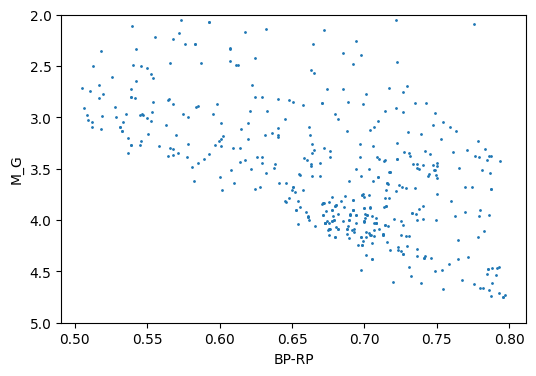

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.scatter(reusable["bp_rp"], reusable["M_G"],  s=1)


ax.set_xlabel("BP-RP")
ax.set_ylabel("M_G")
ax.set_ylim(5,2)

## Age vs. rotation-period proxy（error bars + mass colorbar）

`reusable_frames` の各フレームについて、`rot_evol.py` の `posterior_mean_std` を使い、mistfit posterior から `age`, `radius`, `star_mass`（なければ `mass`）、分光posteriorから `vsini`, `feh` の平均と標準偏差を読む。

傾斜角 $i$ が不明なので、真の $P_{rot}$ ではなく

$$\frac{P_{rot}}{\sin i}=\frac{2\pi R}{v\sin i}$$

を表示する。横方向は年齢の標準偏差、縦方向はradiusと$ v\sin i$の標準偏差を伝播した誤差である。点の色はstellar massを表す。

In [42]:
from rot_evol import DAY_S, R_SUN_KM, SPEC_LABEL, posterior_mean_std
from tqdm.auto import tqdm

# 同じframe_idが複数行に現れた場合も、一つの解析結果として一度だけ読む。
reusable_frames = reusable.drop_duplicates("frame_id").copy()


def _mass_mean_std(iso_path):
    """mistfitの世代によるstar_mass/massの変数名の違いを吸収する。"""
    try:
        return posterior_mean_std(iso_path, "star_mass")
    except KeyError:
        return posterior_mean_std(iso_path, "mass")


def load_rotation_proxy_with_errors(table):
    rows = []
    problems = []

    for row in tqdm(table.itertuples(index=False), total=len(table), unit="frame"):
        iso_path = Path(row.mcmc_path)
        spec_path = iso_path.parent.parent / SPEC_LABEL / "mcmc.nc"
        try:
            age, age_err = posterior_mean_std(iso_path, "age")
            radius, radius_err = posterior_mean_std(iso_path, "radius")
            mass, mass_err = _mass_mean_std(iso_path)
            vsini, vsini_err = posterior_mean_std(spec_path, "vsini")
            feh, feh_err = posterior_mean_std(spec_path, "feh")
            if min(age, radius, mass, vsini) <= 0:
                raise ValueError("age, radius, mass, and vsini must be positive")

            period_over_sini = 2 * np.pi * radius * R_SUN_KM / (vsini * DAY_S)
            period_over_sini_err = period_over_sini * np.sqrt(
                (radius_err / radius) ** 2 + (vsini_err / vsini) ** 2
            )
            rows.append({
                "frame_id": row.frame_id,
                "age_Gyr": age,
                "age_err_Gyr": age_err,
                "P_rot_over_sini_days": period_over_sini,
                "P_rot_over_sini_err_days": period_over_sini_err,
                "mass_Msun": mass,
                "mass_err_Msun": mass_err,
                "radius_Rsun": radius,
                "radius_err_Rsun": radius_err,
                "vsini_km_s": vsini,
                "vsini_err_km_s": vsini_err,
                "feh_dex": feh,
                "feh_err_dex": feh_err,
            })
        except Exception as exc:
            problems.append({
                "frame_id": row.frame_id,
                "iso_path": str(iso_path),
                "spec_path": str(spec_path),
                "error": repr(exc),
            })

    return pd.DataFrame(rows), pd.DataFrame(problems)


rotation_proxy, rotation_load_problems = load_rotation_proxy_with_errors(reusable_frames)
print(f"plot rows: {len(rotation_proxy):,}")
print(f"skipped frames: {len(rotation_load_problems):,}")



  0%|          | 0/457 [00:00<?, ?frame/s]

plot rows: 457
skipped frames: 0


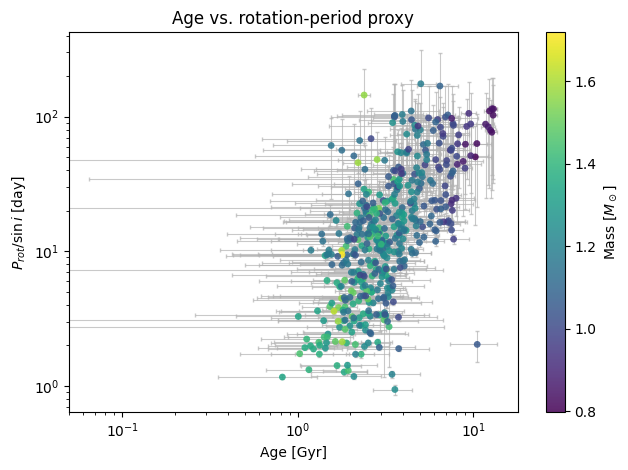

In [43]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.errorbar(
    rotation_proxy["age_Gyr"],
    rotation_proxy["P_rot_over_sini_days"],
    xerr=rotation_proxy["age_err_Gyr"],
    yerr=rotation_proxy["P_rot_over_sini_err_days"],
    fmt="none",
    ecolor="0.7",
    elinewidth=0.8,
    capsize=1.5,
    alpha=0.7,
    zorder=1,
)
points = ax.scatter(
    rotation_proxy["age_Gyr"],
    rotation_proxy["P_rot_over_sini_days"],
    c=rotation_proxy["mass_Msun"],
    cmap="viridis",
    s=24,
    alpha=0.85,
    linewidths=0,
    zorder=2,
)
colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label(r"Mass [$M_\odot$]")
ax.set(
    xscale="log",
    yscale="log",
    xlabel="Age [Gyr]",
    ylabel=r"$P_{rot}/\sin i$ [day]",
    title="Age vs. rotation-period proxy",
)
# ax.grid(alpha=0.2)
fig.tight_layout()
plt.savefig("../spec/figures/rot_evol_N=457")
plt.show()

In [44]:
rotation_proxy.keys()

Index(['frame_id', 'age_Gyr', 'age_err_Gyr', 'P_rot_over_sini_days',
       'P_rot_over_sini_err_days', 'mass_Msun', 'mass_err_Msun', 'radius_Rsun',
       'radius_err_Rsun', 'vsini_km_s', 'vsini_err_km_s', 'feh_dex',
       'feh_err_dex'],
      dtype='object')

In [45]:
rotation_proxy["logage"] = np.log10(rotation_proxy["age_Gyr"])+9
rotation_proxy["logP_rot_over_sini"] = np.log10(rotation_proxy["P_rot_over_sini_days"])

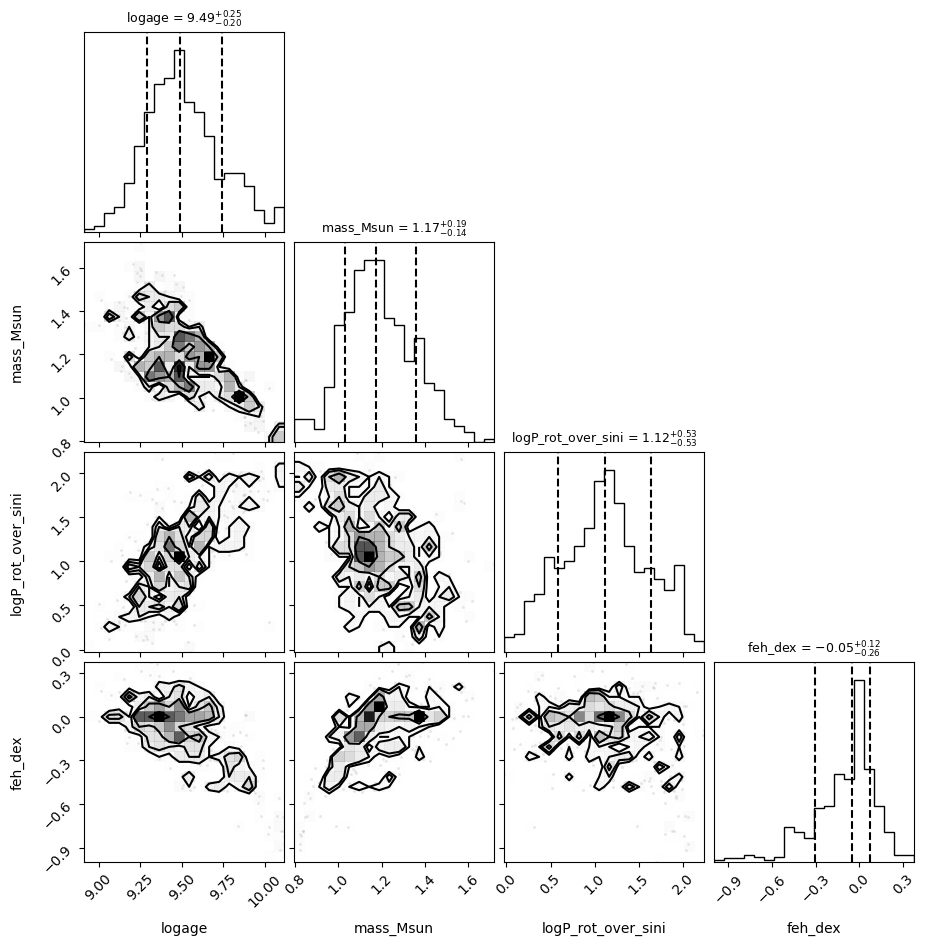

In [46]:
import corner

fig = corner.corner(
    rotation_proxy,
    var_names=["logage", "mass_Msun","logP_rot_over_sini", "feh_dex"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 9},
)
plt.savefig("../spec/figures/26A-N-CN12/corner_N=457.png", bbox_inches="tight")

## 保存

GAOES アーカイブの全観測ログと注釈から `Count (e-)`, `Frame`, `Object`, `Tags` を直接取得する。Web 画面からダウンロードした CSV のフィルター状態には依存しない。

In [47]:
OBSERVATION_COLUMNS = ["Count (e-)", "Frame", "Object", "Tags"]

if "frame_id" not in reusable.columns or "date" not in reusable.columns:
    raise KeyError("frame_id/date is missing from reusable results")


def load_gaoes_archive_module(builder_path):
    spec = importlib.util.spec_from_file_location("gaoes_archive_builder", builder_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load GAOES archive builder: {builder_path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def load_archive_payload(html_path):
    marker = "const DATA = "
    archive_html = html_path.read_text(encoding="utf-8")
    start = archive_html.find(marker)
    if start < 0:
        raise ValueError(f"Archive payload was not found in {html_path}")
    payload, _ = json.JSONDecoder().raw_decode(archive_html[start + len(marker):])
    return payload


gaoes_archive = load_gaoes_archive_module(GAOES_ARCHIVE_BUILDER)
archive_logs, _, _ = gaoes_archive.scan_logs()
archive_payload = load_archive_payload(GAOES_ARCHIVE_HTML)
archived_tags = archive_payload.get("objectTags", {})
annotations = gaoes_archive.load_object_annotations()

observation_records = []
for row in archive_logs["rows"]:
    date = str(row.get("date", "")).strip()
    frame = str(row.get("frame", "")).strip()
    object_name = str(row.get("object", "")).strip()
    object_key = gaoes_archive.object_key(date, object_name)
    annotation = annotations.get(object_key, {})
    if isinstance(annotation, dict) and isinstance(annotation.get("tags"), list):
        tags = annotation["tags"]
    else:
        tags = archived_tags.get(object_key, [])
    tags = sorted({str(tag).strip() for tag in tags if str(tag).strip()})
    observation_records.append(
        {
            "Count (e-)": row.get("count", ""),
            "Frame": frame,
            "Object": object_name,
            "Tags": "; ".join(tags),
            "_date_key": date,
            "_frame_key": gaoes_archive.frame_key(frame),
        }
    )

observation_metadata = pd.DataFrame.from_records(observation_records)
duplicate_keys = observation_metadata.duplicated(["_date_key", "_frame_key"], keep=False)
if duplicate_keys.any():
    duplicated_frames = observation_metadata.loc[
        duplicate_keys, ["_date_key", "Frame"]
    ].to_dict("records")
    raise ValueError(f"Duplicate archive frame keys: {duplicated_frames}")

reusable_to_save = reusable.copy()
reusable_to_save["frame_id"] = reusable_to_save["frame_id"].astype("string").str.strip()
reusable_to_save["_date_key"] = reusable_to_save["date"].astype("string").str.strip()
reusable_to_save["_frame_key"] = reusable_to_save["frame_id"].map(gaoes_archive.frame_key)
reusable_to_save = reusable_to_save.merge(
    observation_metadata,
    how="left",
    on=["_date_key", "_frame_key"],
    validate="many_to_one",
    indicator="_gaoes_archive_match",
)
matched_count = reusable_to_save["_gaoes_archive_match"].eq("both").sum()
print(f"GAOES archive matches: {matched_count:,}/{len(reusable_to_save):,}")
reusable_to_save = reusable_to_save.drop(
    columns=["_date_key", "_frame_key", "_gaoes_archive_match"]
)
output_columns = [
    *OBSERVATION_COLUMNS,
    *[column for column in reusable_to_save.columns if column not in OBSERVATION_COLUMNS],
]
reusable_to_save = reusable_to_save.loc[:, output_columns]
reusable_to_save.to_csv(OUTPUT_CSV, index=False)
print(f"saved {len(reusable_to_save):,} rows to {OUTPUT_CSV.resolve()}")

GAOES archive matches: 457/457
saved 457 rows to /mnt/ogawa/work/rot_evol/reusable_star_gaia.csv
